In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pymatgen.core import Structure, Composition, Lattice      #pymatgen means python material genomics
print("Imports done")


Imports done


In [7]:
lattice=Lattice.cubic(5.43) #edge length will be 5.43
si = Structure(  
    lattice,["Si","Si"],[[0,0,0],[0.25,0.25,0.25]])       # it takes the edge length from lattice, how many elements,and the positions of the elements
print(f"formula: {si.formula}")
print(f"atoms: {si.num_sites}") #total number of atomic sites
print(f"volume:{si.volume:.2f}") #5.43 **3 
print(f"density:{si.density:.3f}") # .3f means apporox 3 digits after decimal point f means float ,: means formatting instruction
print(si.composition)
print(f"mass: {si.composition.weight}")

formula: Si2
atoms: 2
volume:160.10
density:0.583
Si2
mass: 56.171 amu


In [8]:
from pymatgen.core import Element
comp=Composition("GaAs")
print(f"Elements: {list(comp.elements)}")
ga=Element("Ga") # it give access to all the properties of Ga.
print(f"Atomic number: {ga.Z}")
print(f"electronegativity: {ga.X}")
print(f"atomic radius: {ga.atomic_radius}")
print(f"atomic weight: {ga.atomic_mass}")

Elements: [Element Ga, Element As]
Atomic number: 31
electronegativity: 1.81
atomic radius: 1.3 ang
atomic weight: 69.723 amu


In [9]:
from mp_api.client import MPRester
api_key="HCdJoVajvCUxImHdiNAoWIEoZOHE05XZ"
with MPRester(api_key) as mpr:
    entries=mpr.materials.summary.search(
        band_gap=(0.5,3.5),
        num_elements=(2,3),
        num_sites=(2,10),
        fields=["material_id","formula_pretty","band_gap", "formation_energy_per_atom","structure"])
print(f"downloaded {len(entries)} structures with 3D geometry!")


Retrieving SummaryDoc documents:   0%|          | 0/4100 [00:00<?, ?it/s]

downloaded 4100 structures with 3D geometry!


In [10]:
rows=[]
for entry in entries:
    s=entry.structure
    elements=list(s.composition.elements)
    rows.append({
    "formula": entry.formula_pretty,
    "bandgap": entry.band_gap,
    "formation_energy": entry.formation_energy_per_atom,
    "n_sites": s.num_sites,
    "volume": s.volume,
    "density": s.density,
    "volume_per_atm":s.volume / s.num_sites,
    "n_elements": len(elements),
    "mean_electronegativity":np.mean([e.X for e in elements]),
    "electronegativity_diff": max([e.X for e in elements])-min([e.X for e in elements]),
    "mean_atomicmass":np.mean([e.atomic_mass for e in elements]),
    "mean_row": np.mean([e.row for e in elements]),
    "mean_group": np.mean([e.group for e in elements]),
    })
    df_struct=pd.DataFrame(rows)
    df_struct.to_csv("structures_data.csv",index=False)
    print(f"Saved {len(df_struct)} structures with features")
        

    

Saved 1 structures with features
Saved 2 structures with features
Saved 3 structures with features
Saved 4 structures with features
Saved 5 structures with features
Saved 6 structures with features
Saved 7 structures with features
Saved 8 structures with features
Saved 9 structures with features
Saved 10 structures with features
Saved 11 structures with features
Saved 12 structures with features
Saved 13 structures with features
Saved 14 structures with features
Saved 15 structures with features
Saved 16 structures with features
Saved 17 structures with features
Saved 18 structures with features
Saved 19 structures with features
Saved 20 structures with features
Saved 21 structures with features
Saved 22 structures with features
Saved 23 structures with features
Saved 24 structures with features
Saved 25 structures with features
Saved 26 structures with features
Saved 27 structures with features
Saved 28 structures with features
Saved 29 structures with features
Saved 30 structures wit

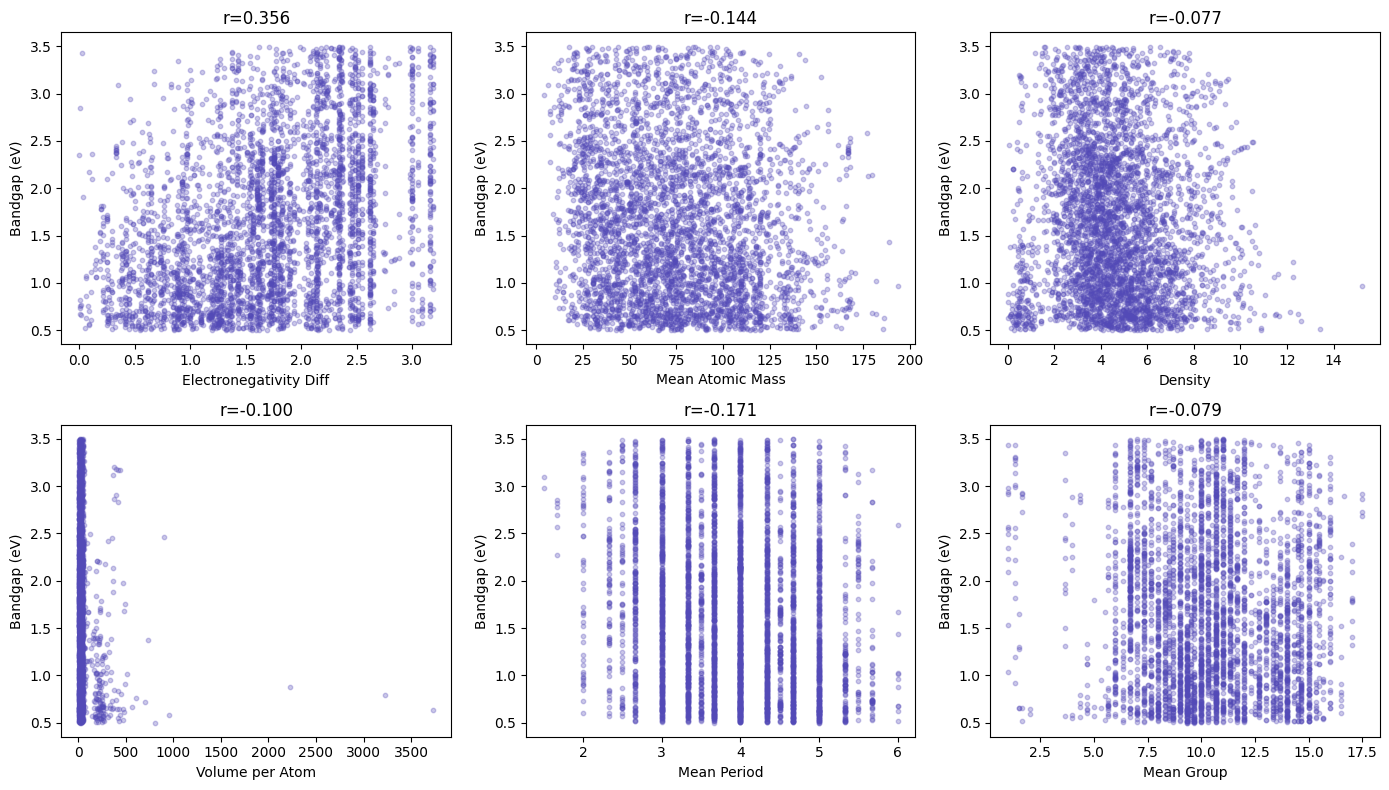

In [16]:
fig,axes=plt.subplots(2,3,figsize=(14,8))
features=[
    ('electronegativity_diff','Electronegativity Diff'),
    ('mean_atomicmass','Mean Atomic Mass'),
    ('density','Density'),
    ('volume_per_atm','Volume per Atom'),
    ('mean_row','Mean Period'),
    ('mean_group','Mean Group'),]
for ax,(feat,label) in zip(axes.flat,features):
    ax.scatter(df_struct[feat],df_struct['bandgap'],
               alpha=0.3,s=10,color='#534AB7')
    corr=df_struct[feat].corr(df_struct['bandgap'])
    ax.set_xlabel(label)
    ax.set_ylabel('Bandgap (eV)')
    ax.set_title(f'r={corr:.3f}')
plt.tight_layout()
plt.savefig('day3_feature_correlations.png',dpi=150)
plt.show()
                

In [17]:
import json
structures_json=[]
for entry in entries:
    structures_json.append({
        "material_id": entry.material_id,
        "formula": entry.formula_pretty,
        "bandgap": entry.band_gap,
        "structure": entry.structure.as_dict()})
with open("structures.json","w") as f:
    json.dump(structures_json,f)
print(f"Saved {len(structures_json)} structures!")

Saved 4100 structures!


In [23]:
from pymatgen.io.cif import CifWriter

cif_text = str(CifWriter(entries[0].structure))

with open("test_structure.cif", "wt", encoding="utf-8") as f:
    f.write(cif_text)

print("Open this in VESTA — download free from jp-minerals.org/vesta/en/")

Open this in VESTA — download free from jp-minerals.org/vesta/en/
